# Hospital Appointment Scheduling Optimization

## Project Overview

This project analyzes hospital appointment data to understand appointment demand, cancellations, no-shows, waiting time, and appointment-slot utilization.

The goal is to identify scheduling patterns and provide practical recommendations to help the hospital manage appointment capacity more effectively.

## Tools and Libraries

* Python
* Pandas
* NumPy
* Matplotlib
* Seaborn


## Business Problem

The hospital wants to understand appointment demand and identify scheduling problems such as cancellations, no-shows, and longer waiting times.

The analysis will help the hospital identify appointment patterns and areas where scheduling can be improved.

## Business Objectives

1. Analyze appointment demand across different departments and time slots.

2. Understand cancellation and no-show patterns.

3. Analyze waiting time across different departments.

4. Identify areas where appointment scheduling can be improved.


## 3. Data Loading

In [1]:
# Import the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Upload the dataset
from google.colab import files
uploaded = files.upload()

Saving hospital_appointments.csv to hospital_appointments.csv


In [3]:
# Load the dataset
df = pd.read_csv('hospital_appointments.csv')

In [4]:
# Display the first 5 rows of the dataset
df.head()

,Appointment_ID,Appointment_Date,Department,Doctor,Patient_Age,Gender,Appointment_Time,Appointment_Duration,Appointment_Status,Booking_Days_Advance,Waiting_Time_Min,Patient_Satisfaction,Available_Slots,Booked_Slots,Used_Slots
0,APT0001,2025-01-07,Cardiology,Dr. Arjun,46,Female,16:00,45,Completed,13,18,5.0,18,1,1
1,APT0002,2025-01-29,Pediatrics,Dr. Asha,1,Female,11:00,15,Completed,2,12,4.0,15,3,2
2,APT0003,2025-11-29,Orthopedics,Dr. Suresh,65,Male,10:00,20,Completed,7,28,2.0,15,1,1
3,APT0004,2025-05-09,Dermatology,Dr. Priya,22,Female,12:00,20,Completed,15,26,2.0,15,2,2
4,APT0005,2025-06-04,General Medicine,Dr. Kavya,41,Female,10:00,20,Completed,7,19,5.0,30,2,2


In [5]:
# Display the last 5 rows of the dataset
df.tail()

,Appointment_ID,Appointment_Date,Department,Doctor,Patient_Age,Gender,Appointment_Time,Appointment_Duration,Appointment_Status,Booking_Days_Advance,Waiting_Time_Min,Patient_Satisfaction,Available_Slots,Booked_Slots,Used_Slots
1995,APT1996,2025-11-06,Dermatology,Dr. Rahul,60,Male,15:00,20,Completed,4,24,4.0,15,1,1
1996,APT1997,2025-09-08,Pediatrics,Dr. Asha,2,Male,09:00,20,Completed,5,16,5.0,15,2,2
1997,APT1998,2025-04-16,General Medicine,Dr. Ramesh,28,Male,17:00,30,Completed,30,27,4.0,30,1,1
1998,APT1999,2025-03-14,General Medicine,Dr. Anil,63,Female,09:00,30,Completed,10,20,5.0,30,5,4
1999,APT2000,2025-04-08,General Medicine,Dr. Anil,40,Male,14:00,20,Completed,3,41,1.0,30,3,3


In [6]:
# Check the number of rows and columns
df.shape

(2000, 15)

In [7]:
# Display all column names
df.columns

Index(['Appointment_ID', 'Appointment_Date', 'Department', 'Doctor',
       'Patient_Age', 'Gender', 'Appointment_Time', 'Appointment_Duration',
       'Appointment_Status', 'Booking_Days_Advance', 'Waiting_Time_Min',
       'Patient_Satisfaction', 'Available_Slots', 'Booked_Slots',
       'Used_Slots'],
      dtype='object')

## 4. Data Understanding

In [8]:
# Check the data type of each column
df.dtypes

,0
Appointment_ID,object
Appointment_Date,object
Department,object
Doctor,object
Patient_Age,int64
Gender,object
Appointment_Time,object
Appointment_Duration,int64
Appointment_Status,object
Booking_Days_Advance,int64


In [9]:
# Check basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Appointment_ID        2000 non-null   object 
 1   Appointment_Date      2000 non-null   object 
 2   Department            2000 non-null   object 
 3   Doctor                2000 non-null   object 
 4   Patient_Age           2000 non-null   int64  
 5   Gender                2000 non-null   object 
 6   Appointment_Time      2000 non-null   object 
 7   Appointment_Duration  2000 non-null   int64  
 8   Appointment_Status    2000 non-null   object 
 9   Booking_Days_Advance  2000 non-null   int64  
 10  Waiting_Time_Min      2000 non-null   int64  
 11  Patient_Satisfaction  1528 non-null   float64
 12  Available_Slots       2000 non-null   int64  
 13  Booked_Slots          2000 non-null   int64  
 14  Used_Slots            2000 non-null   int64  
dtypes: float64(1), int64(

In [10]:
# Check the unique appointment statuses
df['Appointment_Status'].unique()

array(['Completed', 'Cancelled', 'No-Show'], dtype=object)

In [11]:
# Check the unique departments
df['Department'].unique()

array(['Cardiology', 'Pediatrics', 'Orthopedics', 'Dermatology',
       'General Medicine'], dtype=object)

## 5. Data Cleaning

In [12]:
# Check the number of missing values in each column
df.isnull().sum()

,0
Appointment_ID,0
Appointment_Date,0
Department,0
Doctor,0
Patient_Age,0
Gender,0
Appointment_Time,0
Appointment_Duration,0
Appointment_Status,0
Booking_Days_Advance,0


In [13]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

In [14]:
# Check for duplicate Appointment IDs
df['Appointment_ID'].duplicated().sum()

np.int64(0)

In [15]:
# Convert Appointment_Date to proper date format
df['Appointment_Date'] = pd.to_datetime(df['Appointment_Date'])

In [16]:
# Check the appointment status values and their counts
df['Appointment_Status'].value_counts()

,count
Appointment_Status,
Completed,1528
Cancelled,245
No-Show,227


## 6. Descriptive Statistics

In [17]:
# Calculate mean, median, and standard deviation of waiting time
print("Mean Waiting Time:", np.mean(df['Waiting_Time_Min']))
print("Median Waiting Time:", np.median(df['Waiting_Time_Min']))
print("Standard Deviation:", np.std(df['Waiting_Time_Min']))

Mean Waiting Time: 17.7375
Median Waiting Time: 20.0
Standard Deviation: 12.244614887778217


In [18]:
# Calculate mean, median, and standard deviation of appointment duration
print("Mean Appointment Duration:", np.mean(df['Appointment_Duration']))
print("Median Appointment Duration:", np.median(df['Appointment_Duration']))
print("Standard Deviation:", np.std(df['Appointment_Duration']))

Mean Appointment Duration: 24.38
Median Appointment Duration: 20.0
Standard Deviation: 8.552227779941314


In [19]:
# Calculate mean, median, and standard deviation of patient age
print("Mean Patient Age:", np.mean(df['Patient_Age']))
print("Median Patient Age:", np.median(df['Patient_Age']))
print("Standard Deviation:", np.std(df['Patient_Age']))

Mean Patient Age: 41.3815
Median Patient Age: 45.0
Standard Deviation: 21.68757611514022


In [20]:
# Calculate mean, median, and standard deviation of patient satisfaction
print("Mean Patient Satisfaction:", np.nanmean(df['Patient_Satisfaction']))
print("Median Patient Satisfaction:", np.nanmedian(df['Patient_Satisfaction']))
print("Standard Deviation:", np.nanstd(df['Patient_Satisfaction']))

Mean Patient Satisfaction: 3.657068062827225
Median Patient Satisfaction: 4.0
Standard Deviation: 0.9895738098850351


In [21]:
# Display summary statistics for important numerical columns
df[['Patient_Age', 'Appointment_Duration',
    'Waiting_Time_Min', 'Patient_Satisfaction']].describe()

,Patient_Age,Appointment_Duration,Waiting_Time_Min,Patient_Satisfaction
count,2000.0000,2000.000000,2000.000000,1528.000000
mean,41.3815,24.380000,17.737500,3.657068
std,21.6930,8.554367,12.247677,0.989898
min,1.0000,15.000000,0.000000,1.000000
25%,27.0000,20.000000,7.000000,3.000000
50%,45.0000,20.000000,20.000000,4.000000
75%,58.0000,30.000000,27.000000,4.000000
max,80.0000,45.000000,51.000000,5.000000


## 7. Appointment Analysis

In [22]:
# Count the number of appointments by status
df['Appointment_Status'].value_counts()

,count
Appointment_Status,
Completed,1528
Cancelled,245
No-Show,227


In [23]:
# Count the number of appointments by department
df['Department'].value_counts()

,count
Department,
General Medicine,705
Cardiology,384
Dermatology,316
Pediatrics,305
Orthopedics,290


In [24]:
# Count appointment status for each department
pd.crosstab(df['Department'], df['Appointment_Status'])

Appointment_Status,Cancelled,Completed,No-Show
Department,,,
Cardiology,49,285,50
Dermatology,32,245,39
General Medicine,88,547,70
Orthopedics,35,225,30
Pediatrics,41,226,38


In [25]:
# Count the number of appointments by time slot
df['Appointment_Time'].value_counts().sort_index()

,count
Appointment_Time,
09:00,244
10:00,356
11:00,375
12:00,161
14:00,324
15:00,237
16:00,177
17:00,126


In [26]:
# Count appointment status for each time slot
pd.crosstab(df['Appointment_Time'], df['Appointment_Status'])

Appointment_Status,Cancelled,Completed,No-Show
Appointment_Time,,,
09:00,34,192,18
10:00,37,281,38
11:00,46,274,55
12:00,17,128,16
14:00,40,247,37
15:00,33,172,32
16:00,21,139,17
17:00,17,95,14


### Waiting Time Analysis

In [27]:
# Calculate average waiting time by department
df.groupby('Department')['Waiting_Time_Min'].mean().sort_values(ascending=False)


,Waiting_Time_Min
Department,
Dermatology,22.069620
General Medicine,19.587234
Orthopedics,17.358621
Cardiology,15.054688
Pediatrics,12.711475


## 8. Data Visualization

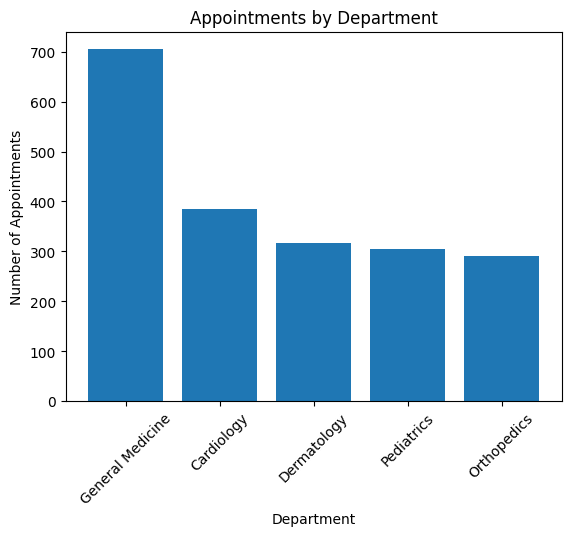

In [28]:
# Plot the number of appointments by department
department_counts = df['Department'].value_counts()

plt.bar(department_counts.index, department_counts.values)
plt.xlabel("Department")
plt.ylabel("Number of Appointments")
plt.title("Appointments by Department")
plt.xticks(rotation=45)
plt.show()

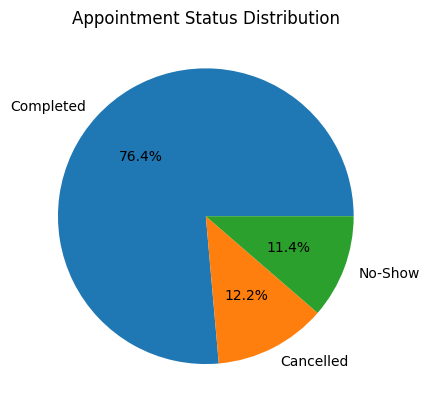

In [29]:
# Plot the appointment status distribution
status_counts = df['Appointment_Status'].value_counts()

plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%')
plt.title("Appointment Status Distribution")
plt.show()

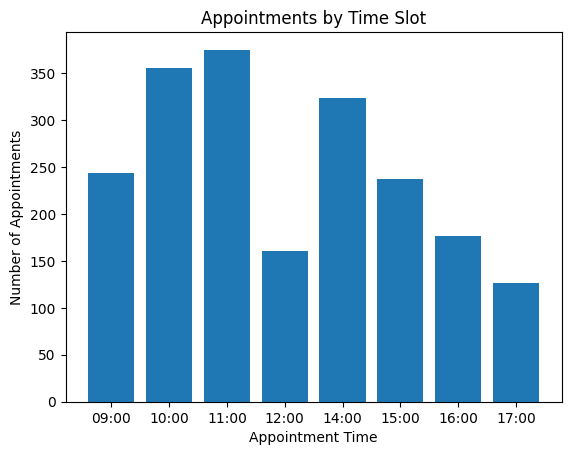

In [30]:
# Plot the number of appointments by time slot
time_counts = df['Appointment_Time'].value_counts().sort_index()

plt.bar(time_counts.index, time_counts.values)
plt.xlabel("Appointment Time")
plt.ylabel("Number of Appointments")
plt.title("Appointments by Time Slot")
plt.show()

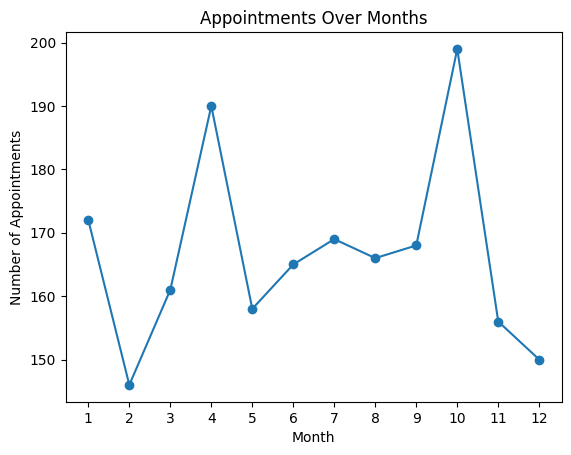

In [31]:
# Plot the number of appointments by month
monthly_counts = df.groupby(df['Appointment_Date'].dt.month).size()

plt.plot(monthly_counts.index, monthly_counts.values, marker='o')
plt.xlabel("Month")
plt.ylabel("Number of Appointments")
plt.title("Appointments Over Months")
plt.xticks(range(1, 13))
plt.show()

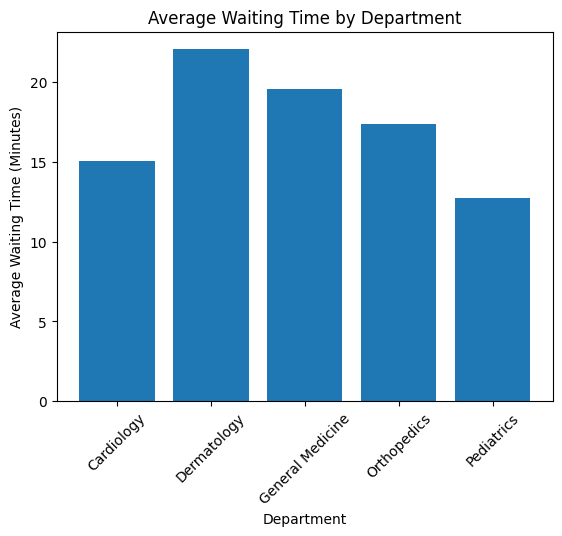

In [32]:
# Plot average waiting time by department
avg_waiting = df.groupby('Department')['Waiting_Time_Min'].mean()

plt.bar(avg_waiting.index, avg_waiting.values)
plt.xlabel("Department")
plt.ylabel("Average Waiting Time (Minutes)")
plt.title("Average Waiting Time by Department")
plt.xticks(rotation=45)
plt.show()

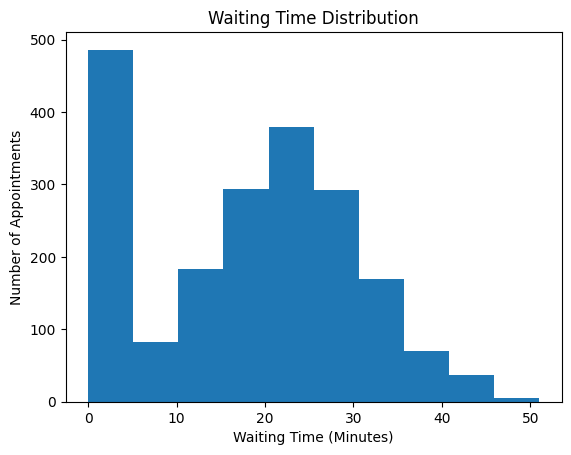

In [33]:
# Plot the distribution of waiting time
plt.hist(df['Waiting_Time_Min'], bins=10)
plt.xlabel("Waiting Time (Minutes)")
plt.ylabel("Number of Appointments")
plt.title("Waiting Time Distribution")
plt.show()

## 9. Business Insights

1. General Medicine has the highest number of appointments.

2. 11:00 AM has the highest appointment demand among the available time slots.

3. Most appointments are completed, while some are cancelled or marked as no-shows.

4. Dermatology has the highest average waiting time, around 22 minutes.

5. Pediatrics has the lowest average waiting time, around 13 minutes.

6. Waiting time varies across appointments, so some patients may experience longer waiting periods.

## 10. Recommendations

1. Allocate more appointment capacity during high-demand time slots.

2. Monitor departments with higher waiting times and improve scheduling where needed.

3. Track cancellations and no-shows to reduce the impact of cancellations and no-shows.

4. Review lower-demand time slots and adjust appointment capacity based on demand.

5. Regularly analyze appointment data to improve hospital scheduling and patient experience.

## 11. Conclusion

This project helped me understand hospital appointment patterns using Python.

I analyzed appointment demand, appointment status, time slots, and waiting time across different departments. The analysis showed that General Medicine had the highest appointment volume, 11:00 AM had the highest demand, and Dermatology had the highest average waiting time.

These insights can help the hospital improve appointment scheduling, manage busy time slots, and reduce waiting time for patients.